In [16]:
import pandas as pd
import seaborn as sns
import numpy as np

from pathlib import Path

### Set up theme and algorithm labels

In [17]:
sns.set_theme(style="darkgrid")

In [18]:
label_map = {
    'bdmmprime': 'BDMM-Prime', 
    'bdmmflow': 'F', 
    'bdmmflow_random': 'F RP',
    'bdmmflow_preconditioner': 'F AIP',
    'bdmmflow_random_inverse': 'IF RP',
    'bdmmflow_preconditioner_inverse': 'IF AIP',
}

order = [
    "F", "F AIP",
    "IF", "IF AIP", 
]

### Load benchmark results

Run from `beast_benchmarks/` to read each dataset's `out/*.out` files. Extracts algorithm settings, runtimes in hours, completed iterations, and mean relative log-likelihood deviations.

In [ ]:
import re

results = []

# Mapping function for algorithm label
def algorithm_label(preconditioner, inverse_flow):
    preconditioner = preconditioner.lower() if preconditioner else ""
    inverse_flow = inverse_flow.lower() if inverse_flow else ""
    if preconditioner == "identity" and inverse_flow == "false":
        return 'F'
    elif preconditioner == "random" and inverse_flow == "false":
        return 'F RP'
    elif preconditioner == "average_inverse" and inverse_flow == "false":
        return 'F AIP'
    elif preconditioner == "random" and inverse_flow == "true":
        return 'IF RP'
    elif preconditioner == "average_inverse" and inverse_flow == "true":
        return 'IF AIP'
    elif preconditioner == "identity" and inverse_flow == "true":
        return 'IF'
    else:
        return 'BDMM-Prime'

for dataset_folder in Path().glob("*"):
    if not dataset_folder.is_dir(): continue

    out_folder = dataset_folder / "out"
    if not out_folder.exists(): continue

    for result_file in out_folder.glob("*.out"):
        # Expect filename: $(filebase).$(preconditioner).$(inverseFlow).$(maxConditioningNumber).$(useLoucaPennellIntervals).$(seed).out
        parts = result_file.stem.split(".")
        # Defensive parse: fallback to None if missing
        (
            filebase,
            preconditioner,
            inverse_flow,
            max_conditioning_number,
            use_louca_pennell_intervals,
            seed
        ) = (
            parts[0] if len(parts) > 0 else None,
            parts[1] if len(parts) > 1 else None,
            parts[2] if len(parts) > 2 else None,
            parts[3] if len(parts) > 3 else None,
            parts[4] if len(parts) > 4 else None,
            parts[5] if len(parts) > 5 else None,
        )

        if seed is None:
            seed = result_file.stem.split(".")[-1].split("_")[-1]

        # Obtain the algorithm label for this line
        algorithm = algorithm_label(preconditioner, inverse_flow)

        # Convert max_conditioning_number to float, use_louca_pennell_intervals to bool, seed to str/int
        try:
            max_conditioning_number_val = float(max_conditioning_number)
        except Exception:
            max_conditioning_number_val = None
        try:
            use_louca_pennell_intervals_val = (use_louca_pennell_intervals.lower() == 'true')
        except Exception:
            use_louca_pennell_intervals_val = None

        # Now parse result file contents
        with open(result_file, "r") as f:
            content = f.read()

            # Find calculation time
            match = re.search(r"Total calculation time: ([\d\.]+) seconds", content)
            # Find the last line with "Msamples" and extract the iterations number at the start of the line
            last_iter_match = None
            for line in reversed(content.splitlines()):
                if re.search(r"\d+[hms]+/Msamples", line.replace(" ", "")): # quick check that this line has something like '1h43m55s/Msamples'
                    m = re.match(r"\s*(\d+)\s", line)
                    if m:
                        last_iter_match = m
                        break

            # Find the last "Mean deviation was ..." line and parse its value
            mean_deviation = None
            mean_dev_pattern = re.compile(r"Mean deviation was ([\d\.eE+-]+)")
            for line in reversed(content.splitlines()):
                match_dev = mean_dev_pattern.search(line)
                if match_dev:
                    mean_deviation = float(match_dev.group(1))
                    break

            if "Killed" in content or "OutOfMemoryError" in content or "Exception" in content:
                iterations = np.nan
            else:
                iterations = int(last_iter_match.group(1)) if last_iter_match else None

            if match:
                calculation_time = float(match.group(1))
                results.append({
                    "dataset": dataset_folder.name,
                    "algorithm": algorithm,
                    "calculation_time": calculation_time / 60 / 60,
                    "iterations": iterations,
                    "mean_deviation": mean_deviation,
                    "seed": seed,
                    "maxConditioningNumber": max_conditioning_number_val,
                    "useLoucaPennellIntervals": use_louca_pennell_intervals_val or False,
                    "intervals": "Louca and Pennell" if (use_louca_pennell_intervals_val or False) else "Ours"
                })
            else:
                calculation_time = np.inf

                results.append({
                    "dataset": dataset_folder.name,
                    "algorithm": algorithm,
                    "calculation_time": calculation_time / 60 / 60,
                    "iterations": iterations,
                    "mean_deviation": mean_deviation,
                    "seed": seed,
                    "maxConditioningNumber": max_conditioning_number_val,
                    "useLoucaPennellIntervals": use_louca_pennell_intervals_val or False,
                    "intervals": "Louca and Pennell" if (use_louca_pennell_intervals_val or False) else "Ours"
                })

df = pd.DataFrame(
    results,
    columns=[
        "dataset", "algorithm", "calculation_time", "iterations",
        "mean_deviation", "seed", "maxConditioningNumber", "useLoucaPennellIntervals", "intervals"
    ]
)

### Summarize benchmark results

Compare completed iterations with matching BDMM-Prime runs and summarize results by dataset, algorithm, and interval strategy.

In [20]:
# For each row, compare iterations to corresponding bdmmprime trial and compute speedup
def compute_speedup(row):
    # Find matching bdmmprime for the same dataset and trial
    mask = (
        (df["dataset"] == row["dataset"]) &
        (df["algorithm"] == "BDMM-Prime") &
        (df["seed"] == row["seed"])
    )
    prime_row = df[mask]
    if not prime_row.empty and pd.notnull(prime_row.iloc[0]["iterations"]) and pd.notnull(row["iterations"]):
        speedup = row["iterations"] / prime_row.iloc[0]["iterations"] if row["iterations"] != 0 else np.nan
        return speedup
    else:
        return np.nan

df["prime_speedup"] = df.apply(compute_speedup, axis=1)

In [21]:
df[["dataset", "algorithm", "calculation_time", "iterations", "useLoucaPennellIntervals"]].dropna().groupby(
    ["useLoucaPennellIntervals", "dataset", "algorithm"]
).count()

calculation_time  iterations
useLoucaPennellIntervals dataset algorithm                               
False                    H3N2    BDMM-Prime                16          16
                                 F                         16          16
                                 F AIP                     16          16
                                 F RP                      16          16
                                 IF                        16          16
                                 IF AIP                    16          16
                                 IF RP                     16          16
                         mers    BDMM-Prime                16          16
                                 F                         16          16
                                 F AIP                     16          16
                                 F RP                      16          16
                                 IF                        16          16
                                 IF AIP                    16          16
                                 IF RP                     16          16
True                     H3N2    F                         11          11
                                 F AIP                      9           9
                                 F RP                       8           8
                                 IF                        16          16
                                 IF AIP                    16          16
                                 IF RP                     16          16
                         mers    F                         16          16
                                 F AIP                     16          16
                                 F RP                      16          16
                                 IF                        16          16
                                 IF AIP                    16          16
                                 IF RP                     16          16

In [22]:
df[["dataset", "algorithm", "calculation_time", "iterations", "useLoucaPennellIntervals"]].groupby(
    ["useLoucaPennellIntervals", "dataset", "algorithm"]
).median()

calculation_time   iterations
useLoucaPennellIntervals dataset algorithm                                
False                    H3N2    BDMM-Prime         28.516412   10000000.0
                                 F                  14.575696   10000000.0
                                 F AIP              13.868848   10000000.0
                                 F RP               13.121198   10000000.0
                                 IF                 15.043882   10000000.0
                                 IF AIP             13.848425   10000000.0
                                 IF RP              12.995229   10000000.0
                         mers    BDMM-Prime               inf   33128000.0
                                 F                  33.245477  100000000.0
                                 F AIP              32.473014  100000000.0
                                 F RP               30.122723  100000000.0
                                 IF                 34.412834  100000000.0
                                 IF AIP             30.964703  100000000.0
                                 IF RP              29.415569  100000000.0
True                     H3N2    F                  32.645938   10000000.0
                                 F AIP              46.118036   10000000.0
                                 F RP                     inf   10000000.0
                                 IF                 17.144944   10000000.0
                                 IF AIP             14.447064   10000000.0
                                 IF RP              13.660349   10000000.0
                         mers    F                  35.309635  100000000.0
                                 F AIP              34.278578  100000000.0
                                 F RP               32.460338  100000000.0
                                 IF                 35.377147  100000000.0
                                 IF AIP             31.516794  100000000.0
                                 IF RP              30.450641  100000000.0

### Explore accuracy and progress

Compare likelihood deviations and completed iterations across algorithms and interval strategies.

In [ ]:
g = sns.FacetGrid(
    df.dropna(subset=["mean_deviation"]),
    row="dataset",
    col="useLoucaPennellIntervals",
    sharey=True,
    aspect=1.4,
    margin_titles=True
)
g.map(sns.boxplot, "algorithm", "mean_deviation", order=order, showfliers=True)

# Set y-axis to log scale for both facets and add more descriptive axis labels
for col_idx, col_val in enumerate(sorted(df["useLoucaPennellIntervals"].dropna().unique())):
    for row_idx, row_val in enumerate(sorted(df["dataset"].dropna().unique())):
        try:
            ax = g.axes[row_idx][col_idx]
            ax.set_yscale("log")
            ax.set_xlabel("Algorithm")
            ax.set_ylabel("Mean rel log deviation" if row_idx == 0 else "")
        except Exception:
            pass

# Add nice facet titles
g.set_titles(row_template="{row_name}", col_template="Use Louca–Pennell Intervals: {col_name}")
g.tick_params(axis='x', labelrotation=30)

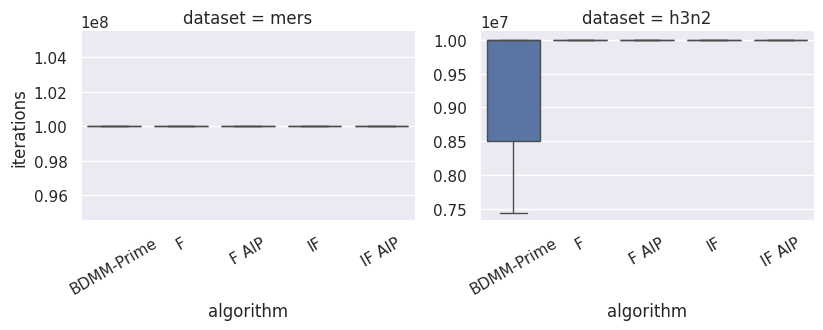

In [ ]:
g = sns.FacetGrid(df[(df.iterations != np.nan) & ~(df.useLoucaPennellIntervals == True)], col="dataset", sharey=False, aspect=1.4)

g.map(sns.boxplot, "algorithm", "iterations", showfliers=False, order=["BDMM-Prime"] + order)
g.tick_params(axis='x', labelrotation=30)

/cluster/home/ochsneto/bdmm/BDMM-Flow-Supplementary/.venv/lib/python3.9/site-packages/seaborn/axisgrid.py:723: UserWarning: Using the boxplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)


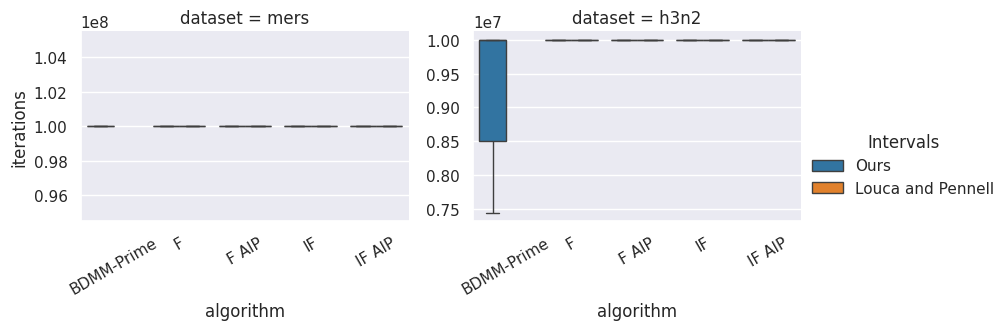

In [ ]:
g = sns.FacetGrid(df[(df.iterations != np.nan)], col="dataset", sharey=False, aspect=1.4)

g.map(sns.boxplot, "algorithm", "iterations", "intervals", showfliers=False, order=["BDMM-Prime"] + order, palette='tab10')
g.tick_params(axis='x', labelrotation=30)
g.add_legend(title="Intervals")

### Compare runtimes by interval strategy

Inspect runtime distributions for each dataset and interval strategy.

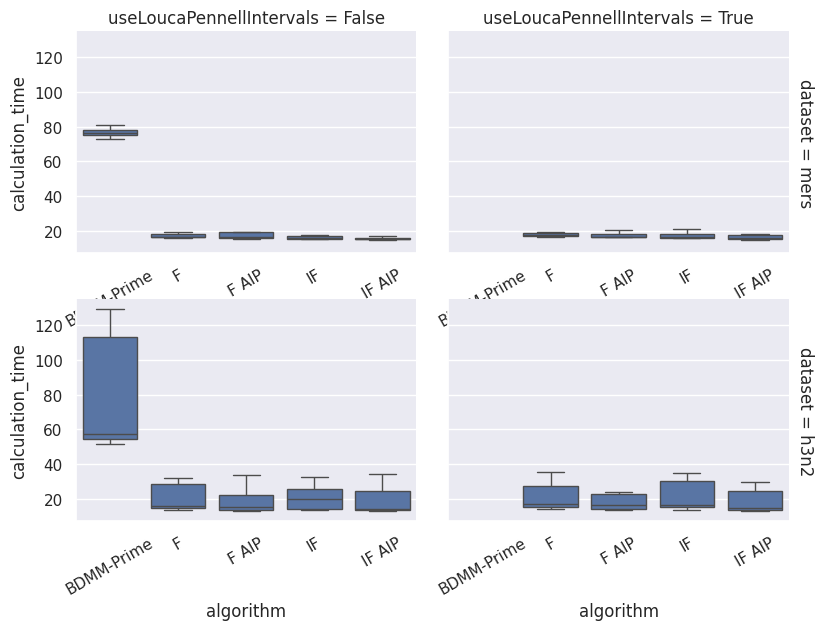

In [ ]:
g = sns.FacetGrid(
    df[(df.calculation_time != np.inf)], 
    col="useLoucaPennellIntervals",
    row="dataset", 
    sharey=True, 
    sharex=False,
    aspect=1.4,
    margin_titles=True
)
g.map(sns.boxplot, "algorithm", "calculation_time", showfliers=False, order=["BDMM-Prime"] + order)
g.tick_params(axis='x', labelrotation=30)

### Runtime plot (Figure 7)

Compare BEAST runtimes for MERS-CoV and H3N2 using our interval strategy, with median annotations. Save the plot as `runtime_real.svg`.

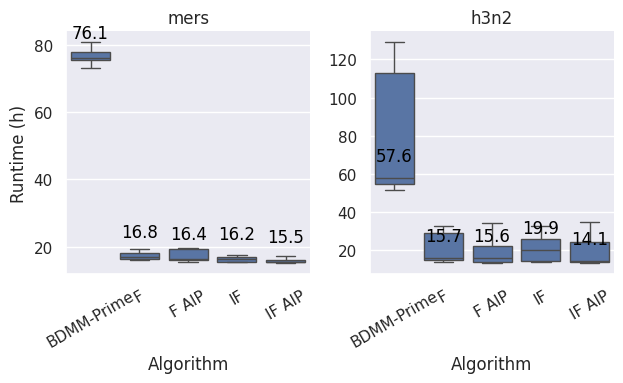

In [ ]:
g = sns.FacetGrid(
    df[(df.calculation_time != np.inf) & (df.intervals == "Ours")], 
    col="dataset",
    sharey=False,
    aspect=0.8,
    height=4,
    margin_titles=True,
)
g.map(
    sns.boxplot, "algorithm", "calculation_time",
    showfliers=False, order=["BDMM-Prime"] + order
)
g.tick_params(axis='x', labelrotation=30)

g.set_axis_labels("Algorithm", "Runtime (h)")
g.set_titles(col_template="{col_name}", row_template="{row_name}")

# Add median labels above each boxplot
full_order = ["BDMM-Prime"] + order
dataset_cols = [t.get_text() for t in g.axes.flat[0].get_xticklabels()] # fallback
for ax, (_, facet_data) in zip(g.axes.flat, g.facet_data()):
    y_max = ax.get_ylim()[1]
    for i, algo in enumerate(full_order):
        vals = facet_data.loc[
            facet_data["algorithm"] == algo, "calculation_time"
        ].dropna()
        if vals.empty:
            continue
        median = vals.median()

        y_pos = median + (ax.get_ylim()[1] + ax.get_ylim()[0]) * 0.05

        ax.text(
            i, y_pos,
            f"{median:.1f}",
            ha="center", va="bottom",
            fontsize=12, 
            color="black",
        )

g.tight_layout()
g.savefig("runtime_real.svg")

### Likelihood comparison plot (Figure 8)

Compare mean relative log-likelihood deviations from BDMM-Prime for MERS-CoV and H3N2 using our interval strategy. Save the plot as `deviation_real.svg`.

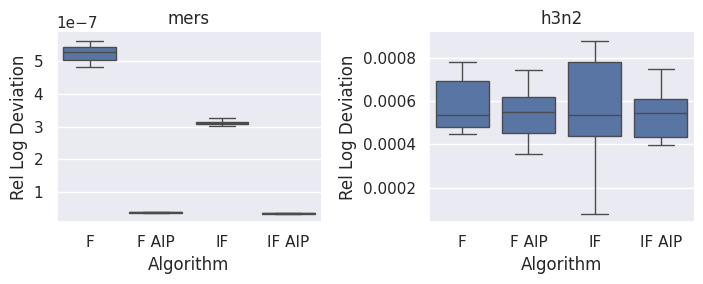

In [ ]:
g = sns.FacetGrid(
    df[df.intervals == "Ours"].dropna(subset=["mean_deviation"]),
    col="dataset",
    sharey=False,
    aspect=1.2,
    margin_titles=True,
    height=3,
)
g.map(sns.boxplot, "algorithm", "mean_deviation", order=order, showfliers=False)

# Set y-axis to log scale for both facets and add more descriptive axis labels
for col_idx, col_val in enumerate(sorted(df["useLoucaPennellIntervals"].dropna().unique())):
    for row_idx, row_val in enumerate(sorted(df["dataset"].dropna().unique())):
        try:
            ax = g.axes[row_idx][col_idx]
            ax.set_xlabel("Algorithm")
            ax.set_ylabel("Rel Log Deviation" if row_idx == 0 else "")
        except Exception:
            pass

g.set_titles(col_template="{col_name}", row_template="{row_name}")

g.tight_layout()
g.savefig("deviation_real.svg")

### Additional interval comparisons

Compare runtime and likelihood deviation between our interval strategy and the Louca-Pennell strategy.

/cluster/home/ochsneto/bdmm/BDMM-Flow-Supplementary/.venv/lib/python3.9/site-packages/seaborn/axisgrid.py:723: UserWarning: Using the boxplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)


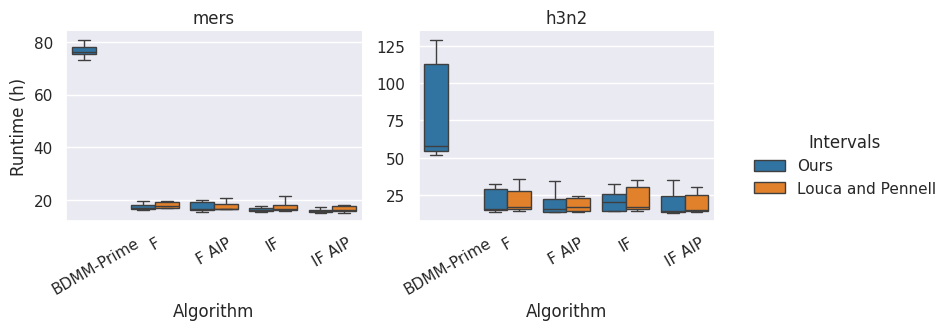

In [ ]:
g = sns.FacetGrid(
    df[(df.calculation_time != np.inf)], 
    col="dataset",
    sharey=False,
    sharex=False,
    aspect=1.3,
    margin_titles=True
)
g.map(
    sns.boxplot, "algorithm", "calculation_time", "intervals", 
    showfliers=False, order=["BDMM-Prime"] + order,
    palette='tab10'
)
g.add_legend(title="Intervals")
g.tick_params(axis='x', labelrotation=30)

g.set_axis_labels("Algorithm", "Runtime (h)")
g.set_titles(col_template="{col_name}", row_template="{row_name}")

/cluster/home/ochsneto/bdmm/BDMM-Flow-Supplementary/.venv/lib/python3.9/site-packages/seaborn/axisgrid.py:723: UserWarning: Using the boxplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)


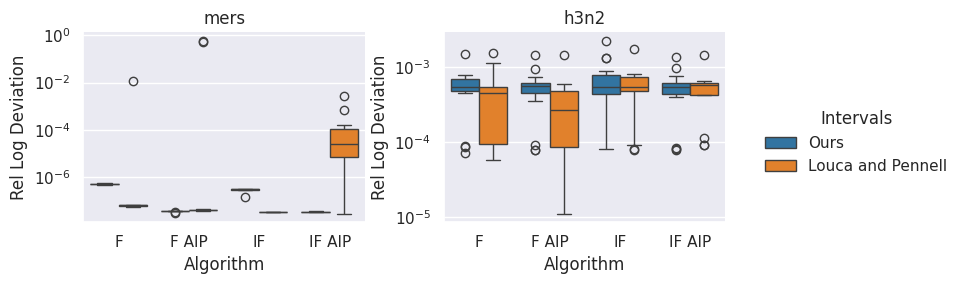

In [ ]:
g = sns.FacetGrid(
    df.dropna(subset=["mean_deviation"]),
    col="dataset",
    sharey=False,
    aspect=1.3,
    margin_titles=True
)
g.map(sns.boxplot, "algorithm", "mean_deviation", "intervals", order=order, showfliers=True, palette='tab10')

# Set y-axis to log scale for both facets and add more descriptive axis labels
for col_idx, col_val in enumerate(sorted(df["useLoucaPennellIntervals"].dropna().unique())):
    for row_idx, row_val in enumerate(sorted(df["dataset"].dropna().unique())):
        try:
            ax = g.axes[row_idx][col_idx]
            ax.set_xlabel("Algorithm")
            ax.set_ylabel("Rel Log Deviation" if row_idx == 0 else "")
            ax.set_yscale("log")
        except Exception:
            pass

g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.add_legend(title="Intervals")